In [2]:
!uv add geopandas pandas 

import geopandas as gpd
import pandas as pd

# read_file em CSV nao converte a coluna WKT 'geom' -> DataFrame comum
df = pd.read_csv("./data/vw_snv_rod.csv")
gdf = gpd.GeoDataFrame(
    df.drop(columns="geom"),
    geometry=gpd.GeoSeries.from_wkt(df["geom"]),
    crs="EPSG:4326",
)

Resolved 113 packages in 10ms
Audited 109 packages in 0.61ms


In [3]:
# --- CIDES 2021 ---
df_cide = pd.read_csv("./data/vw_cide_rod_2021(1).csv")
cide = gpd.GeoDataFrame(
    df_cide.drop(columns="geom"),
    geometry=gpd.GeoSeries.from_wkt(df_cide["geom"]),
    crs="EPSG:4326",
)

In [4]:
# --- CIDES 2021 ---
df_sede_muni = pd.read_csv("./data/vw_sedes_municipais.csv")
df_sede_muni = gpd.GeoDataFrame(
    df_sede_muni.drop(columns="geom"),
    geometry=gpd.GeoSeries.from_wkt(df_sede_muni["geom"]),
    crs="EPSG:4326",
)

In [5]:
# Municipios IBGE 2024 
mun = gpd.read_file("zip://data/BA_Municipios_2024.zip")
mun = mun.to_crs("EPSG:4326")

In [6]:
# filtro por trechos Baianos
sede_muni = df_sede_muni[df_sede_muni["Nome_Sede"].isin(mun["NM_MUN"])]
rod_fed_ba = gdf[gdf["Unidade_Federacao"] == "BA"]
rod_est_ba = cide[cide["Unidade_Federacao"] == "BA"]
rod_est_ba = rod_est_ba[rod_est_ba["Jurisdicao"] != "Federal"]
rod_est_ba["Codigo"] = "BA-" + rod_est_ba["Codigo_Rodovia"].astype(str)
rod_fed_ba["Codigo"] = "BR-" + rod_fed_ba["Codigo_BR"].astype(str)


len(rod_est_ba), len(rod_fed_ba)

(1611, 674)

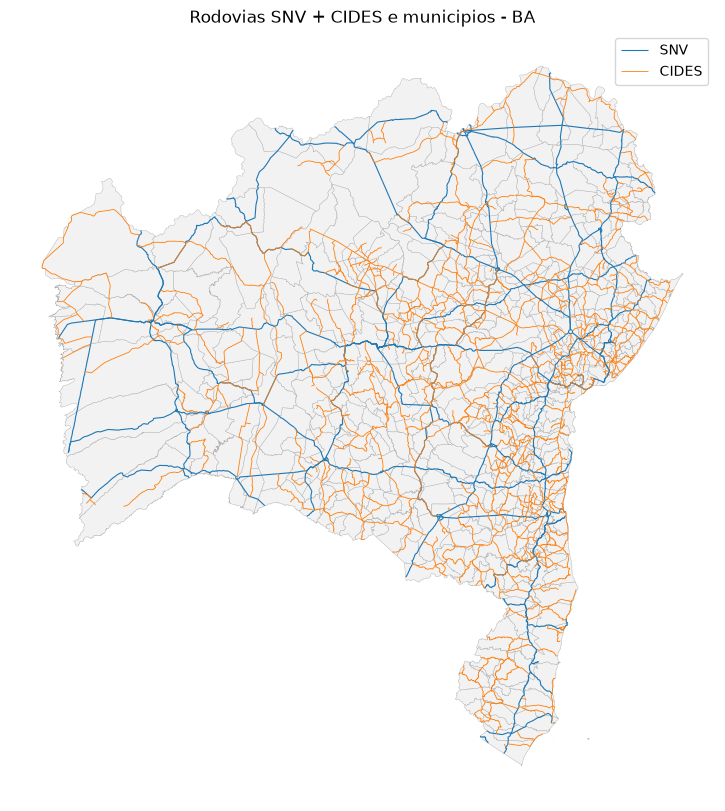

In [7]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))
mun.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#b0b0b0", linewidth=0.3)
#sede_muni.plot(ax=ax, facecolor="#fe00fe", linewidth=0.5)
rod_fed_ba.plot(ax=ax, color="#1f77b4", linewidth=0.8, label="SNV")
rod_est_ba.plot(ax=ax, color="#ff7f0e", linewidth=0.6, label="CIDES")
ax.set_title("Rodovias SNV + CIDES e municipios - BA")
ax.set_axis_off()
ax.legend()


#ax = rod_est_ba.plot(figsize=(12, 10), linewidth=0.4)
#ax.set_title("Trechos rodoviarios Estaduais - BA")

#bx = rod_fed_ba.plot(figsize=(12, 10), linewidth=0.5)
#bx.set_title("Trechos rodoviarios Federais - BA (SNV)")


In [8]:
# --- Conexoes rodovia x municipio (spatial join) ---
col_mun = mun[["CD_MUN", "NM_MUN", "geometry"]]
#rod_116 = rod_fed_join[rod_fed_join["Codigo_BR"] == 116]
#rod_116 = rod_fed_join
rod_ba = pd.concat([rod_fed_ba, rod_est_ba], ignore_index=True)

sub = gpd.overlay(rod_ba, col_mun,
                  how="intersection", keep_geom_type=True)       # cada linha = 1 sub-trecho

sub = sub.explode(index_parts=False).reset_index(drop=True)
sub["segment_id"] = sub["Codigo_SNV"] + "_" + sub.index.astype(str)
sub["comprimento_km"] = sub.to_crs(5880).geometry.length / 1000

rod_join = gpd.sjoin(rod_ba, col_mun, how="inner", predicate="intersects")


trechos_por_mun = (
    rod_join
    .groupby(["CD_MUN", "NM_MUN"])
    .size()
    .rename("n_trechos")
    .reset_index()
)

print("Municipios com mais trechos (SNV + CIDES):")
print(trechos_por_mun.sort_values("n_trechos", ascending=False).head(10).to_string(index=False))
print()

print("Rodovias que conectam mais municipios:")
print(rod_join.groupby("Codigo")["NM_MUN"].nunique().sort_values(ascending=False).head(10).to_string())


Municipios com mais trechos (SNV + CIDES):
 CD_MUN               NM_MUN  n_trechos
2905701             Camaçari         48
2913606               Ilhéus         39
2918407             Juazeiro         37
2918001               Jequié         37
2910503           Entre Rios         30
2910800     Feira de Santana         29
2933307 Vitória da Conquista         28
2903201            Barreiras         28
2927200          Ruy Barbosa         26
2913002             Ibitiara         24

Rodovias que conectam mais municipios:
Codigo
BR-101    62
BA-120    40
BR-349    33
BR-116    33
BR-242    31
BR-330    29
BR-407    28
BR-30     26
BA-130    25
BA-001    25


In [9]:

fields = ['id_snv', 'Codigo', 'Unidade_Federacao', 'Sigla_Tipo_Trecho',
       'Nome_Tipo_Trecho', 'Codigo_SNV',
       'Local_Inicio', 'Local_Fim', 'Extensao',
       'geometry', 'NM_MUN']
rod_ba = rod_join[fields]


In [10]:
sub

,FID,id_snv,Codigo_BR,Unidade_Federacao,Sigla_Tipo_Trecho,Nome_Tipo_Trecho,Codigo_SNV,Coincidencia_Federal,Local_Inicio,Local_Fim,...,Tipo_Revestimento,Convenio,MP082,Jurisdicao,Referencia,CD_MUN,NM_MUN,geometry,segment_id,comprimento_km
0,vw_snv_rod.fid-d22bd82_1a0641a2a5b_-1522,340926.0,324.0,BA,B,Eixo Principal,324BBA0390,324BBA0390,AMÉLIA RODRIGUES,ENTR BA-515 (P/JACUÍPE),...,NaN,NaN,NaN,NaN,NaN,2901106,Amélia Rodrigues,"LINESTRING (-38.75514 -12.40341, -38.75455 -12...",324BBA0390_0,13.727403
1,vw_snv_rod.fid-d22bd82_1a0641a2a5b_-1522,340926.0,324.0,BA,B,Eixo Principal,324BBA0390,324BBA0390,AMÉLIA RODRIGUES,ENTR BA-515 (P/JACUÍPE),...,NaN,NaN,NaN,NaN,NaN,2901106,Amélia Rodrigues,"LINESTRING (-38.65234 -12.49348, -38.65224 -12...",324BBA0390_1,1.307811
2,vw_snv_rod.fid-d22bd82_1a0641a2a5b_-1522,340926.0,324.0,BA,B,Eixo Principal,324BBA0390,324BBA0390,AMÉLIA RODRIGUES,ENTR BA-515 (P/JACUÍPE),...,NaN,NaN,NaN,NaN,NaN,2928604,Santo Amaro,"LINESTRING (-38.66545 -12.48378, -38.66535 -12...",324BBA0390_2,1.807116
3,vw_snv_rod.fid-d22bd82_1a0641a2a5b_-1520,340972.0,330.0,BA,B,Eixo Principal,330BBA0115,330BBA0115,ENTR BA-161 (BARRA),FIM PONTE S/RIO SÃO FRANCISCO,...,NaN,NaN,NaN,NaN,NaN,2902708,Barra,"LINESTRING (-43.13297 -11.07646, -43.1311 -11....",330BBA0115_3,1.240136
4,vw_snv_rod.fid-d22bd82_1a0641a2a5b_-1520,340972.0,330.0,BA,B,Eixo Principal,330BBA0115,330BBA0115,ENTR BA-161 (BARRA),FIM PONTE S/RIO SÃO FRANCISCO,...,NaN,NaN,NaN,NaN,NaN,2933604,Xique-Xique,"LINESTRING (-43.12276 -11.08125, -43.12063 -11...",330BBA0115_4,0.447116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4671,vw_cide_rod_2021.fid-d22bd82_1a0641a2a5b_77f5,NaN,NaN,BA,NaN,NaN,142EBA0040,NaN,ENTR FEDERAL PLANEJADA BR-349,ENTR BR 242 (A),...,TS,NaN,NaN,Estadual,cide2021,2933406,Wagner,"LINESTRING (-41.17901 -12.29631, -41.17902 -12...",142EBA0040_4671,10.062601
4672,vw_cide_rod_2021.fid-d22bd82_1a0641a2a5b_77f5,NaN,NaN,BA,NaN,NaN,142EBA0040,NaN,ENTR FEDERAL PLANEJADA BR-349,ENTR BR 242 (A),...,TS,NaN,NaN,Estadual,cide2021,2901304,Andaraí,"LINESTRING (-41.09747 -12.47099, -41.09743 -12...",142EBA0040_4672,0.004608
4673,vw_cide_rod_2021.fid-d22bd82_1a0641a2a5b_77f5,NaN,NaN,BA,NaN,NaN,142EBA0040,NaN,ENTR FEDERAL PLANEJADA BR-349,ENTR BR 242 (A),...,TS,NaN,NaN,Estadual,cide2021,2919009,Lajedinho,"LINESTRING (-41.14865 -12.37642, -41.1486 -12....",142EBA0040_4673,12.092097
4674,vw_cide_rod_2021.fid-d22bd82_1a0641a2a5b_77f8,NaN,NaN,BA,NaN,NaN,403EBA0015,NaN,ENTR FEDERAL PLANEJADA BR-349(A),ENTR FEDERAL PLANEJADA BR-349(B),...,RP,NaN,NaN,Estadual,cide2021,2929701,Sátiro Dias,"LINESTRING (-38.54664 -11.48863, -38.54671 -11...",403EBA0015_4674,5.699212


In [11]:
pares = gpd.sjoin(
    sub[["segment_id", "geometry"]],
    sub[["segment_id", "geometry"]],
    predicate="intersects",
    how="inner",
    lsuffix="_a",
    rsuffix="_b",
)

pares = pares.drop_duplicates(
    subset=["segment_id__a", "segment_id__b"]
)
pares = pares[
    pares["segment_id__a"] != pares["segment_id__b"]
]
pares

,segment_id__a,geometry,index__b,segment_id__b
0,324BBA0390_0,"LINESTRING (-38.75514 -12.40341, -38.75455 -12...",2,324BBA0390_2
0,324BBA0390_0,"LINESTRING (-38.75514 -12.40341, -38.75455 -12...",1227,324BBA0372_1227
1,324BBA0390_1,"LINESTRING (-38.65234 -12.49348, -38.65224 -12...",1228,324BBA0410_1228
1,324BBA0390_1,"LINESTRING (-38.65234 -12.49348, -38.65224 -12...",2,324BBA0390_2
2,324BBA0390_2,"LINESTRING (-38.66545 -12.48378, -38.66535 -12...",1,324BBA0390_1
...,...,...,...,...
4674,403EBA0015_4674,"LINESTRING (-38.54664 -11.48863, -38.54671 -11...",1318,349BBA0400_1318
4674,403EBA0015_4674,"LINESTRING (-38.54664 -11.48863, -38.54671 -11...",1315,349BBA0395_1315
4674,403EBA0015_4674,"LINESTRING (-38.54664 -11.48863, -38.54671 -11...",4621,403EBA0015_4621
4675,403EBA0015_4675,"LINESTRING (-38.56993 -11.53204, -38.56995 -11...",4624,403EBA0015_4624


In [12]:
import json
from shapely.ops import unary_union

grafo = {}

# ── 1. Municípios e atributos de cada segmento ────────────────────────
for id_seg, grupo in sub.groupby("segment_id"):
    # id pode vir como int64 — normaliza para string (chave JSON)
    id_seg = str(id_seg)

    codigo = grupo["Codigo"].dropna().unique()
    # um segmento pertence a uma única rodovia; se quebrar, seus dados estão sujos
    assert len(codigo) == 1, f"segmento {id_seg} com múltiplas rodovias: {codigo}"

    # comprimento_km por LINHA: cada linha é uma parte do segmento → soma
    # (confirme no seu GeoDataFrame: se o valor for o do segmento inteiro
    # repetido em cada linha, troque .sum() por .iloc[0])
    extensao = round(float(grupo["comprimento_km"].sum()), 3)

    geometry = unary_union(grupo.geometry)

    grafo[id_seg] = {
        "mun": [str(m) for m in grupo["NM_MUN"].unique().tolist()],
        "rodovia": str(codigo[0]),
        "extensao_km": extensao,
        "geometry": geometry.__geo_interface__,
        "conec": [],
    }
    
# ── 2. Conexões espaciais (sjoin) ─────────────────────────────────────
# descarta linhas sem par (sjoin com how="left" gera NaN)
pares = pares.dropna(subset=["segment_id__a", "segment_id__b"])

for _, row in pares.iterrows():
    a = str(row["segment_id__a"])
    b = str(row["segment_id__b"])

    # segmento vizinho de si mesmo (auto-interseção na borda do município)
    if a == b:
        print("auto-conexão ignorada:", a)
        continue

    # segmento que só aparece em `pares` ganha entrada vazia
    grafo.setdefault(a, {"mun": [], "rodovia": "", "extensao_km": None, "conec": [], "geometry": None,
})
    grafo.setdefault(b, {"mun": [], "rodovia": "", "extensao_km": None, "conec": [], "geometry": None})

    grafo[a]["conec"].append(b)
    grafo[b]["conec"].append(a)

# ── 3. Limpeza final ──────────────────────────────────────────────────
for id_seg, dados in grafo.items():
    dados["conec"] = list(dict.fromkeys(dados["conec"]))          # sem repetição
    dados["conec"] = [c for c in dados["conec"] if c in grafo]    # sem referências penduradas
    # extensão desconhecida não vai para o JSON (null cairia em BFS no server)
    if dados["extensao_km"] is None:
        del dados["extensao_km"]

# sane: quantos segmentos ficaram sem extensão?
sem_km = [id_seg for id_seg, d in grafo.items() if "extensao_km" not in d]
print(f"nós: {len(grafo)} | sem extensão: {len(sem_km)}")
if sem_km:
    print("exemplos:", sem_km[:5])

with open("ba_grafo.json", "w", encoding="utf-8") as f:
    json.dump(grafo, f, ensure_ascii=False, indent=2)


nós: 4676 | sem extensão: 0


In [13]:
import json

municipios = gpd.read_file("data/BA_Municipios_2024.zip")

# simplifica em METROS antes de reprojetar (Douglas-Peucker em graus fica distorcido)
municipios["geometry"] = municipios.simplify(
    tolerance=150,              # ~150 m — reduz o tamanho do arquivo
    preserve_topology=True,
)
municipios = municipios.to_crs(epsg=4326)          # WGS84 (lon, lat)
municipios = municipios.rename(columns={"NM_MUN": "nome"})
municipios = municipios[["nome", "geometry"]].sort_values("nome")


shapes = {
    row["nome"]: row["geometry"].__geo_interface__
    for _, row in municipios.iterrows()
}

por_municipio = {}

for municipio, grupo in sub.groupby("NM_MUN"):
    # ids normalizados para string — consistência com as chaves do grafo
    trechos = [str(t) for t in grupo["segment_id"].unique().tolist()]

    # só municípios com trecho de verdade (dropna no NM_MUN, se houver)
    if not trechos:
        continue
        
    por_municipio[str(municipio)] = {
        "shape": shapes[str(municipio)],
        "trechos": trechos,
    }
    
for municipio, dados in por_municipio.items():
    conexoes = {
        vizinho
        for trecho in dados["trechos"]
        if trecho in grafo
        for vizinho in grafo[trecho]["conec"]
    }
    # ordenado para o arquivo ficar estável (diff amigável no git)
    dados["conexoes"] = sorted(conexoes)

with open("ba_grafo_por_municipio.json", "w", encoding="utf-8") as f:
    json.dump(
        dict(sorted(por_municipio.items())),
        f,
        ensure_ascii=False,
        indent=2,
    )


In [41]:
import json


municipios = gpd.read_file("data/BA_Municipios_2024.zip")

# simplifica em METROS antes de reprojetar (Douglas-Peucker em graus fica distorcido)
municipios["geometry"] = municipios.simplify(
    tolerance=150,              # ~150 m — reduz o tamanho do arquivo
    preserve_topology=True,
)
municipios = municipios.to_crs(epsg=4326)          # WGS84 (lon, lat)
municipios = municipios.rename(columns={"NM_MUN": "nome"})
municipios = municipios[["nome", "geometry"]].sort_values("nome")

# re-serializa com acentos legíveis (gpd.to_json escapa \u00e1)
geojson = json.loads(municipios.to_json())
texto = json.dumps(geojson, ensure_ascii=False)

with open("ba_municipios.geojson", "w", encoding="utf-8") as f:
    f.write(texto)

print("municípios:", len(municipios), "| payload (KB):", round(len(texto) / 1024))


municípios: 417 | payload (KB): 99


In [13]:
from collections import deque


def encontrar_caminho(origem, destino, grafo, por_municipio):
    """
    Encontra um caminho entre dois municípios usando
    as conexões espaciais entre os trechos.
    """

    if origem not in por_municipio:
        return None

    if destino not in por_municipio:
        return None

    trechos_origem = set(
        por_municipio[origem]["trechos"]
    )

    trechos_destino = set(
        por_municipio[destino]["trechos"]
    )

    # Cada estado da fila é:
    # (trecho_atual, caminho_percorrido)
    fila = deque()

    visitados = set()

    for trecho in trechos_origem:
        fila.append(
            (trecho, [trecho])
        )
        visitados.add(trecho)

    while fila:

        trecho_atual, caminho = fila.popleft()

        # Chegamos a um trecho pertencente
        # ao município destino
        if trecho_atual in trechos_destino:
            return caminho

        for proximo in grafo.get(
            trecho_atual,
            {}
        ).get("conec", []):

            if proximo in visitados:
                continue

            visitados.add(proximo)

            fila.append(
                (
                    proximo,
                    caminho + [proximo]
                )
            )

    return None

In [14]:
import matplotlib.pyplot as plt


def visualizar_caminho(caminho, rod):
    # Seleciona os trechos pertencentes ao caminho
    trechos_caminho = rod[
        rod["segment_id"].isin(caminho)
    ]

    fig, ax = plt.subplots(figsize=(14, 10))
    mun.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#b0b0b0", linewidth=0.3)
    # BR-116 inteira
    rod.plot(
        ax=ax,
        linewidth=1,
        alpha=0.15
    )

    # Caminho encontrado
    trechos_caminho.plot(
        ax=ax,
        linewidth=2
    )

    # Identificação de cada trecho
    for _, row in trechos_caminho.iterrows():
        ponto = row.geometry.representative_point()

        ax.annotate(
            str(row["NM_MUN"]),
            xy=(ponto.x, ponto.y),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=2
        )

    ax.set_title(
        f"Caminho encontrado — {len(caminho)} trechos"
    )
    print(trechos_caminho["NM_MUN"])
    ax.set_axis_off()
    plt.tight_layout()
    plt.show()

['020BBA0265_79', '135BBA0570_488', '020BBA0270_81', '020BBA0280_69', '020BBA0280_68', '020BBA0290_83', '020BBA0290_82', '020BBA0300_59', '020BBA0300_58', '020BBA0310_60', '020BBA0320_61', '020BBA0320_62', '020BBA0350_64', '020BBA0350_63', '235BBA0345_588', '235BBA0340_587', '235BBA0340_586', '235BBA0330_585', '235BBA0325_584', '324BBA0160_729', '324BBA0160_730', '324BBA0170_523', '324BBA0180_524', '324BBA0185_526', '324BBA0185_525', '324BBA0190_566', '324BBA0190_567', '122BBA0415_415', '324BBA0200_569', '324BBA0210_684', '324BBA0230_685', '324BBA0235_732', '324BBA0238_733', '324BBA0242_735', '324BBA0242_734', '324BBA0245_736', '324BBA0245_737', '324BBA0250_740', '324BBA0250_739', '324BBA0250_738', '324BBA0260_741', '324BBA0265_742', '324BBA0265_743', '324BBA0270_744', '324BBA0270_745', '324BBA0270_746', '324CBA1005_710', '349BBA0470_852', '349BBA0470_850', '349BBA0470_851', '349BBA0470_849']
58                  Buritirama
59                    Mansidão
60                  Buritirama
6

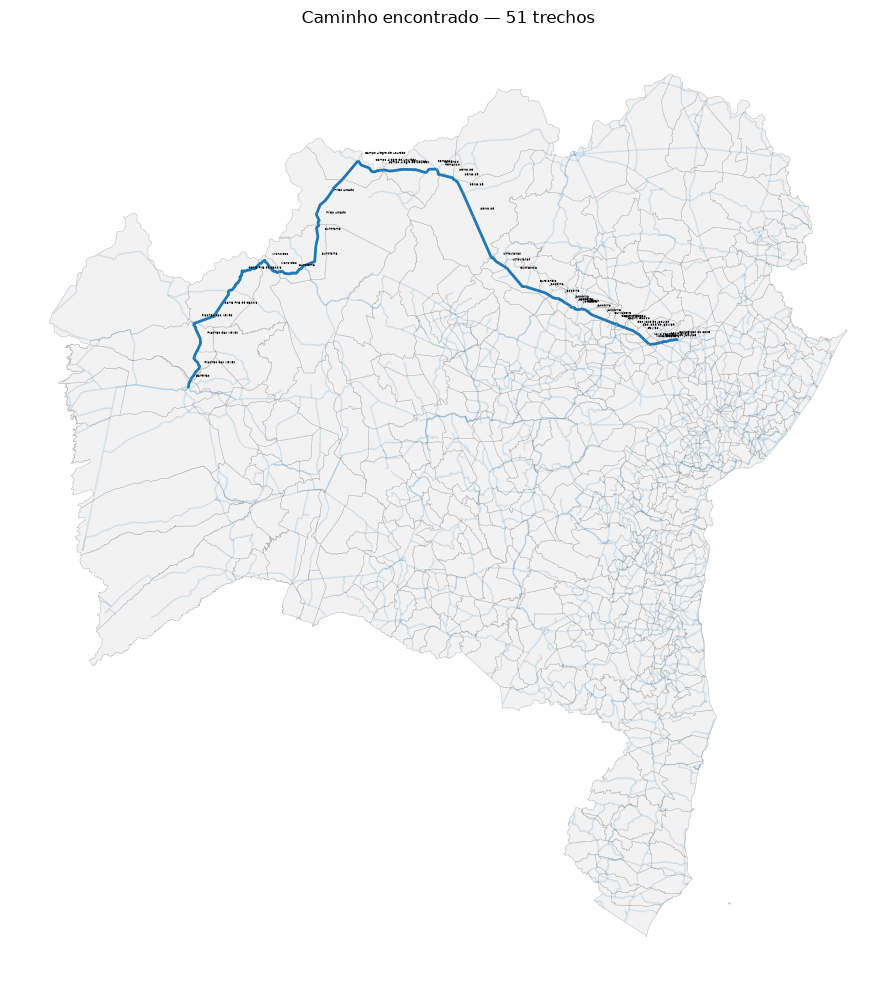

In [15]:
caminho = encontrar_caminho(
       "Barreiras",
    "Conceição do Coité",
 
    grafo,
    por_municipio
)

print(caminho)

visualizar_caminho(
    caminho,
    sub
)

In [16]:
sub = sub.explode(index_parts=False).reset_index(drop=True)
sub["segment_id"] = sub["Codigo_SNV"] + "_" + sub.index.astype(str)
sub["comprimento_km"] = sub.to_crs(5880).geometry.length / 1000

In [17]:
pares = gpd.sjoin(sub[["segment_id", "geometry"]], sub[["segment_id", "geometry"]],
                  predicate="intersects", how="inner", lsuffix="_a", rsuffix="_b")
pares = pares[pares["segment_id__a"] != pares["segment_id__b"]]
pares["u"] = pares[["segment_id__a", "segment_id__b"]].min(axis=1)
pares["v"] = pares[["segment_id__a", "segment_id__b"]].max(axis=1)
pares = pares.drop_duplicates(["u", "v"])

grafo = {}
for u, v in zip(pares["u"], pares["v"]):
    grafo.setdefault(u, set()).add(v)
    grafo.setdefault(v, set()).add(u)


In [18]:
from collections import deque
import heapq


def encontrar_caminho(origem, destino):
    ini = set(sub.loc[sub["NM_MUN"] == origem, "segment_id"])
    fim = set(sub.loc[sub["NM_MUN"] == destino, "segment_id"])
    fila = deque((t, [t]) for t in ini)
    p = []
    
    visto = set(ini)
    while fila:
        atual, caminho = fila.popleft()
        if atual in fim:
            return caminho
        for v in grafo.get(atual, ()) - visto:
            visto.add(v)
            fila.append((v, caminho + [v]))


/tmp/ipykernel_32771/2686202845.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  linha = gpd.GeoSeries([linemerge(rota.unary_union)], crs="EPSG:4326")


['Serra Preta', 'Riachão do Jacuípe', 'Riachão do Jacuípe', 'Riachão do Jacuípe', 'Candeal', 'Tanquinho', 'Tanquinho', 'Santa Bárbara', 'Feira de Santana', 'Feira de Santana', 'Feira de Santana', 'Feira de Santana', 'Feira de Santana', 'Feira de Santana', 'Feira de Santana', 'Feira de Santana', 'São Gonçalo dos Campos']
['BA-120', 'BA-120', 'BR-324', 'BR-324', 'BR-324', 'BR-324', 'BR-324', 'BR-324', 'BR-324', 'BR-324', 'BR-116', 'BR-324', 'BR-324', 'BA-860', 'BR-101', 'BR-101', 'BR-101']
178.38521940487865
Serra Preta -> Riachão do Jacuípe -> Candeal -> Tanquinho -> Santa Bárbara -> Feira de Santana -> São Gonçalo dos Campos


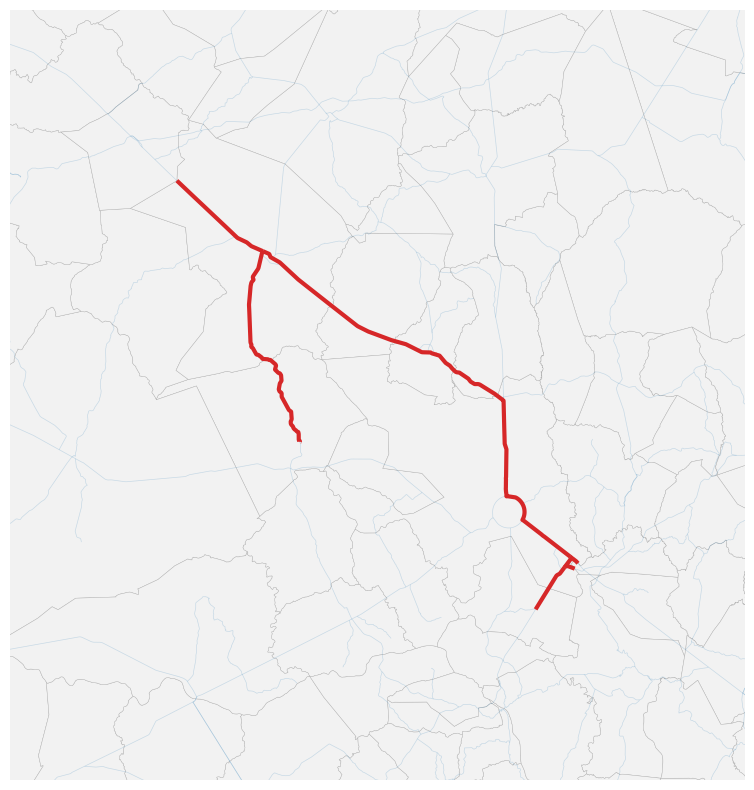

In [19]:
from shapely.ops import linemerge

def visualizar_caminho(caminho):
    seq = sub.set_index("segment_id").loc[caminho]       # ordem do percurso
    rota = gpd.GeoSeries(seq.geometry.tolist(), crs="EPSG:4326")
    minx, miny, maxx, maxy = rota.total_bounds
    fig, ax = plt.subplots(figsize=(14, 10))
    mun.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#b0b0b0", linewidth=0.3)
    sub.plot(ax=ax, linewidth=0.5, alpha=0.2)
    linha = gpd.GeoSeries([linemerge(rota.unary_union)], crs="EPSG:4326")
    linha.plot(ax=ax, linewidth=3, color="#d62728")
    ax.set_xlim(minx - 0.3, maxx + 0.3)
    ax.set_ylim(miny - 0.3, maxy + 0.3)
    ax.set_axis_off()
    return seq

caminho = encontrar_caminho("Serra Preta", "São Gonçalo dos Campos")
seq = visualizar_caminho(caminho)
nome_trechos = list(seq["NM_MUN"])
print(nome_trechos)
print(list(seq["Codigo"]))
print(seq["comprimento_km"].sum())

sequencia = []
for (i,n) in enumerate(nome_trechos):
    if n in sequencia :
        continue
    sequencia.append(n)
print(" -> ".join(sequencia))


In [20]:
te = sub.explode(index_parts=False).reset_index(drop=True)
te = te[~te.geometry.is_empty].reset_index(drop=True)
te["segment_id"] = te["Codigo_SNV"] + "_" + te.index.astype(str)
te["comprimento_km"] = te.to_crs(5880).geometry.length / 1000

import heapq

comp = dict(zip(te["segment_id"], te["comprimento_km"].fillna(0)))

def dijkstra(ini, fim, pen):
    dist = {t: 0.0 for t in ini}
    ant = {}
    fila = [(0.0, t) for t in ini]
    heapq.heapify(fila)
    while fila:
        d, u = heapq.heappop(fila)
        if d > dist.get(u, float("inf")):
            continue
        if u in fim:
            cam = [u]
            while u in ant:
                u = ant[u]
                cam.append(u)
            return cam[::-1]
        for v in grafo.get(u, ()):
            nd = d + pen.get(v, 0.0) + comp.get(v, 0.0)
            if nd < dist.get(v, float("inf")):
                dist[v] = nd
                ant[v] = u
                heapq.heappush(fila, (nd, v))
    return None

def alternativas(origem, destino, k=3):
    ini = set(te.loc[sub["NM_MUN"] == origem, "segment_id"])
    fim = set(te.loc[sub["NM_MUN"] == destino, "segment_id"])
    total = sum(comp.values())
    pen = {}
    res, vistos = [], set()
    for _ in range(k):
        cam = dijkstra(ini, fim, pen)
        if cam is None:
            break
        chave = tuple(te.set_index("segment_id").loc[cam, "Codigo"])
        if chave in vistos:
            break                       # sem alternativa real: para aqui
        vistos.add(chave)
        res.append(cam)
        for sid in cam:
            pen[sid] = pen.get(sid, 0.0) + total   # rota usada fica cara
    return res


In [21]:
def visualizar_alternativas(caminhos):
    if not caminhos:
        print("nenhum caminho encontrado")
        return
    rotas, resumos = [], []
    for c in caminhos:
        seq = sub.set_index("segment_id").loc[c]
        rotas.append(linemerge(gpd.GeoSeries(seq.geometry.tolist()).unary_union))
        resumos.append((len(c), seq["comprimento_km"].sum(),
                        list(dict.fromkeys(seq["Codigo"]))))
    xmin, ymin, xmax, ymax = gpd.GeoSeries(rotas, crs="EPSG:4326").unary_union.bounds
    fig, ax = plt.subplots(figsize=(14, 10))
    mun.plot(ax=ax, facecolor="#f2f2f2", edgecolor="#b0b0b0", linewidth=0.3)
    sub.plot(ax=ax, linewidth=0.5, alpha=0.2)
    for i, rota in enumerate(rotas):
        gpd.GeoSeries([rota], crs="EPSG:4326").plot(ax=ax, linewidth=3, color=f"C{i}")
    ax.set_xlim(xmin - 0.1, xmax + 0.1)
    ax.set_ylim(ymin - 0.1, ymax + 0.1)
    ax.set_axis_off()
    for i, (n, km, rod) in enumerate(resumos, 1):
        print(f"{i}. {n} trechos | {km:.0f} km | rodovias: {rod}")


/tmp/ipykernel_32771/394592328.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rotas.append(linemerge(gpd.GeoSeries(seq.geometry.tolist()).unary_union))
/tmp/ipykernel_32771/394592328.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rotas.append(linemerge(gpd.GeoSeries(seq.geometry.tolist()).unary_union))
/tmp/ipykernel_32771/394592328.py:8: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  rotas.append(linemerge(gpd.GeoSeries(seq.geometry.tolist()).unary_union))
/tmp/ipykernel_32771/394592328.py:11: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  xmin, ymin, xmax, ymax = gpd.GeoSeries(rotas, crs="EPSG:4326").unary_union.bounds


1. 6 trechos | 54 km | rodovias: ['BR-324']
2. 8 trechos | 72 km | rodovias: ['BA-120', 'BA-052']
3. 14 trechos | 60 km | rodovias: ['BA-233', 'BA-411', 'BA-402', 'BR-116']


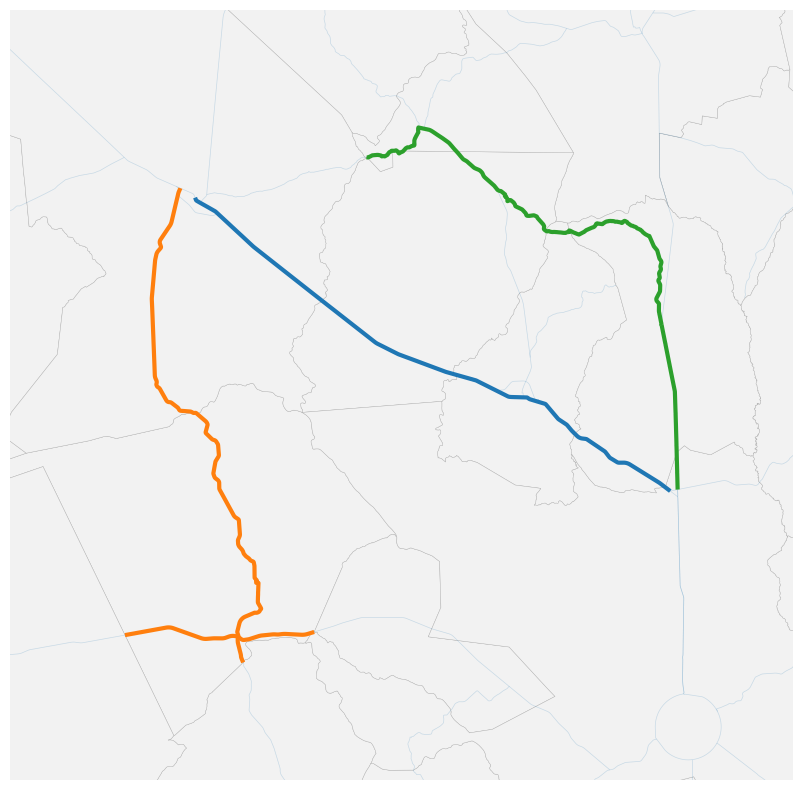

In [26]:
caminhos = alternativas("Riachão do Jacuípe", "Feira de Santana", k=3)
visualizar_alternativas(caminhos)
